GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import glob
import pickle
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [ ]:
!pip install tensorflow

# Step 1: Dataset Preparation

In [ ]:
# Define Dataset Path
dataset_path = "/content/drive/MyDrive/TPW/Drowsiness Detection"

In [ ]:
# Check Folder Structure
print("Dataset Contents:")
print(os.listdir(dataset_path))

Dataset Contents:
['README.roboflow.txt', 'README.dataset.txt', 'test', 'train', 'valid', 'data.yaml']


In [ ]:
# Check Train, Valid, Test Folders
train_path = os.path.join(dataset_path, "train")
valid_path = os.path.join(dataset_path, "valid")
test_path = os.path.join(dataset_path, "test")

print("\nTrain Data:", os.listdir(train_path)[:5])  # Show first 5 files
print("Valid Data:", os.listdir(valid_path)[:5])
print("Test Data:", os.listdir(test_path)[:5])


Train Data: ['images', 'labels.cache', 'labels', 'augmented_images']
Valid Data: ['images', 'labels', 'labels.cache']
Test Data: ['labels', 'images']


# Step 2: Data Preprocessing

In [ ]:
# Define Paths
train_images = glob.glob(os.path.join(train_path, "images", "*.jpg"))  # Adjust if using PNG/JPEG
valid_images = glob.glob(os.path.join(valid_path, "images", "*.jpg"))
test_images = glob.glob(os.path.join(test_path, "images", "*.jpg"))

train_labels = glob.glob(os.path.join(train_path, "labels", "*.txt"))
valid_labels = glob.glob(os.path.join(valid_path, "labels", "*.txt"))

In [ ]:
# Check if all images have corresponding labels
def check_labels(images, labels):
    image_files = {os.path.splitext(os.path.basename(f))[0] for f in images}
    label_files = {os.path.splitext(os.path.basename(f))[0] for f in labels}

    missing_labels = image_files - label_files
    missing_images = label_files - image_files

    print(f"Missing Labels: {len(missing_labels)} | Missing Images: {len(missing_images)}")
    return missing_labels, missing_images

train_missing, _ = check_labels(train_images, train_labels)
valid_missing, _ = check_labels(valid_images, valid_labels)

Missing Labels: 0 | Missing Images: 0
Missing Labels: 0 | Missing Images: 0


In [ ]:
# Remove corrupted images
def remove_corrupted(images):
    for img_path in images:
        try:
            img = cv2.imread(img_path)
            if img is None:
                print(f"Removing corrupted file: {img_path}")
                os.remove(img_path)
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

remove_corrupted(train_images)
remove_corrupted(valid_images)
remove_corrupted(test_images)

print("✅ Data Preprocessing Completed!")

✅ Data Preprocessing Completed!


In [ ]:
transform = A.Compose([
    A.Resize(224, 224),  # Resize to 224x224
    A.HorizontalFlip(p=0.5),  # Randomly flip images
    A.RandomBrightnessContrast(p=0.2),  # Adjust brightness & contrast
    A.Rotate(limit=20, p=0.5),  # Random rotation (-20 to 20 degrees)
    A.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),  # Normalize to 0-1
    ToTensorV2()
])

In [ ]:
TRAIN_PATH = os.path.join(dataset_path, "train/images") # Path to original training images
AUGMENTED_TRAIN_PATH = os.path.join(dataset_path, "train/augmented_images") # Path to save augmented images

In [ ]:
# Function to preprocess and save images
def preprocess_images(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for img_name in tqdm(os.listdir(input_folder), desc="Processing Images"):
        img_path = os.path.join(input_folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue  # Skip unreadable images

        # Resize and normalize image
        img = cv2.resize(img, (224, 224))
        img = img.astype(np.float32) / 255.0  # Normalize

        # Save processed image
        output_path = os.path.join(output_folder, img_name)
        cv2.imwrite(output_path, (img * 255).astype(np.uint8))

# Preprocess Training Images
preprocess_images(TRAIN_PATH, AUGMENTED_TRAIN_PATH)
print("✅ Image Preprocessing Completed!")

Processing Images: 100%|██████████| 352/352 [02:22<00:00,  2.48it/s]

✅ Image Preprocessing Completed!


# Step 3: Convert Images to Sequences for LSTM Input

In [ ]:
TRAIN_PATH = os.path.join(dataset_path, "train/augmented_images")
VALID_PATH = os.path.join(dataset_path, "valid/images")
TEST_PATH = os.path.join(dataset_path, "test/images")

AUGMENTED_TRAIN_PATH = os.path.join(dataset_path, "train/augmented_images")
LABEL_PATH = os.path.join(dataset_path, "train/labels")

In [ ]:
# Ensure the output directory exists
os.makedirs(AUGMENTED_TRAIN_PATH, exist_ok=True)

In [ ]:
# Hyperparameters
SEQUENCE_LENGTH = 10  # Number of frames per sequence
LABEL_MAP = {"Awake": 0, "Drowsy": 1}  # Adjust based on dataset

In [ ]:
# Load Preprocessed Train Images
# Paths to images and labels
image_path = os.path.join(dataset_path, "train/augmented_images")
label_path = os.path.join(dataset_path, "train/labels")

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
def create_sequences(image_filenames, seq_length, image_path, label_path):
    sequences = []
    labels = []

    for i in tqdm(range(len(image_filenames) - seq_length + 1), desc="Creating Sequences"):
        # Create a sequence of image paths
        sequence = [os.path.join(image_path, image_filenames[j]) for j in range(i, i + seq_length)]
        sequences.append(sequence)

        # Fetch corresponding labels
        label_sequence = []
        for j in range(i, i + seq_length):
            label_filename = image_filenames[j].replace(".jpg", ".txt")
            label_filepath = os.path.join(label_path, label_filename)

            if os.path.exists(label_filepath):
                with open(label_filepath, "r") as file:
                    label_content = file.read().strip()
                    label_sequence.append(LABEL_MAP.get(label_content, 0))  # Convert to int
            else:
                print(f"Warning: Label not found for {label_filepath}")
                label_sequence.append(0)  # Default to 'Awake'

        # Use the last label of the sequence for training
        labels.append(to_categorical(label_sequence[-1], num_classes=2))

    return np.array(sequences), np.array(labels)

# Load Image Filenames
train_images = sorted(os.listdir(AUGMENTED_TRAIN_PATH))  # Ensure sorted order

# Convert Training Data to Sequences
train_sequences, train_labels = create_sequences(train_images, SEQUENCE_LENGTH, AUGMENTED_TRAIN_PATH, LABEL_PATH)

Creating Sequences: 100%|██████████| 343/343 [02:53<00:00,  1.98it/s]


In [ ]:
import tensorflow as tf

In [ ]:
# Save Processed Data for Later Use
with open("/content/train_sequences.pkl", "wb") as f:
    pickle.dump(train_sequences, f)

print(f"✅ Created {len(train_sequences)} sequences for training.")

✅ Created 343 sequences for training.


In [ ]:
batch_size = 4  # Adjust as needed

# Function to parse images into tensor format
def parse_function(sequence, label):
    def load_images(seq):
        images = []
        for img_path in seq:
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, (224, 224)) / 255.0  # Normalize
            images.append(img)
        return tf.stack(images)

    images = tf.py_function(func=load_images, inp=[sequence], Tout=tf.float32)
    images.set_shape((SEQUENCE_LENGTH, 224, 224, 3))  # Define static shape for performance
    return images, label

# Convert Training Data to TensorFlow Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_sequences, train_labels))

# Map function with fixed `parse_function`
train_dataset = train_dataset.map(parse_function).batch(batch_size).shuffle(100)

# Check dataset structure
for batch in train_dataset.take(1):
    print(f"✅ Batch shape: {batch[0].shape}, Labels shape: {batch[1].shape}")

✅ Batch shape: (4, 10, 224, 224, 3), Labels shape: (4, 2)


# Step 4: Build the Hybrid CNN + LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2

In [ ]:
# Define input shape: (sequence_length, height, width, channels)
sequence_length = SEQUENCE_LENGTH  # Adjust based on your dataset
img_height, img_width, channels = 224, 224, 3

# Load MobileNetV2 as a feature extractor
base_cnn = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_cnn = Model(inputs=base_cnn.input, outputs=GlobalAveragePooling2D()(base_cnn.output)) # Global pooling

# Make CNN layers non-trainable (Optional: Fine-tune later)
base_cnn.trainable = False

# Wrap CNN in TimeDistributed for sequence processing
cnn_time_distributed = TimeDistributed(base_cnn, input_shape=(sequence_length, img_height, img_width, channels))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# LSTM Model
inputs = Input(shape=(sequence_length, img_height, img_width, channels))
x = TimeDistributed(base_cnn)(inputs)
x = LSTM(64, return_sequences=False)(x)  # LSTM with 64 units
x = Dropout(0.3)(x)  # Prevent overfitting
x = Dense(64, activation="relu", kernel_regularizer=l2(0.01))(x)
outputs = Dense(2, activation="softmax")(x)  # 2 classes: Awake, Drowsy

In [ ]:
model = Model(inputs=inputs, outputs=outputs)
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [ ]:
# Print model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 10, 224, 224, 3)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 10, 1280)            │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │         344,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,606,594 (9.94 MB)

 Trainable params: 348,610 (1.33 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 5: Train & Evaluate the Model

Model Training & Evaluation with Callbacks

In [ ]:
# Define Callbacks
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_loss", mode="min")
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [ ]:
TRAIN_LABELS = os.path.join(dataset_path, "train/labels")
VALID_LABELS = os.path.join(dataset_path, "valid/labels")

In [ ]:
# Train the Model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=train_dataset,  # Placeholder for valid_dataset
    callbacks=[checkpoint, early_stopping]
)

print("✅ Model Training Completed!")

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.0644

86/86 ━━━━━━━━━━━━━━━━━━━━ 127s 738ms/step - accuracy: 1.0000 - loss: 0.0639 - val_accuracy: 1.0000 - val_loss: 1.0875e-04
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 5.2393e-04

86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 389ms/step - accuracy: 1.0000 - loss: 5.2184e-04 - val_accuracy: 1.0000 - val_loss: 2.4320e-05
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 1.4423e-04

86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 386ms/step - accuracy: 1.0000 - loss: 1.4409e-04 - val_accuracy: 1.0000 - val_loss: 8.4715e-06
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 6.7757e-05

86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 386ms/step - accuracy: 1.0000 - loss: 6.7704e-05 - val_accuracy: 1.0000 - val_loss: 4.1376e-06
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 7.4784e-05

...

86/86 ━━━━━━━━━━━━━━━━━━━━ 50s 382ms/step - accuracy: 1.0000 - loss: 3.5553e-05 - val_accuracy: 1.0000 - val_loss: 1.0948e-06
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 2.3297e-05

86/86 ━━━━━━━━━━━━━━━━━━━━ 83s 388ms/step - accuracy: 1.0000 - loss: 2.3287e-05 - val_accuracy: 1.0000 - val_loss: 5.9639e-07
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 2.3630e-05

86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 393ms/step - accuracy: 1.0000 - loss: 2.3524e-05 - val_accuracy: 1.0000 - val_loss: 3.6632e-07
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 7.0355e-06

86/86 ━━━━━━━━━━━━━━━━━━━━ 50s 384ms/step - accuracy: 1.0000 - loss: 7.0848e-06 - val_accuracy: 1.0000 - val_loss: 2.4155e-07
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 3.2875e-06

86/86 ━━━━━━━━━━━━━━━━━━━━ 98s 578ms/step - accuracy: 1.0000 - loss: 3.2834e-06 - val_accuracy: 1.0000 - val_loss: 2.0679e-07
✅ Model Training Completed!


In [ ]:
TEST_PATH = os.path.join(dataset_path, "test/images")

In [ ]:
# Create test sequences (similar to create_sequences for train)
test_image_filenames = sorted(os.listdir(TEST_PATH))
test_sequences, test_labels = create_sequences(test_image_filenames, SEQUENCE_LENGTH, TEST_PATH, LABEL_PATH) # Ensure paths are correct for test data

# Create TensorFlow Dataset for Test Data
test_dataset = tf.data.Dataset.from_tensor_slices((test_sequences, test_labels))
test_dataset = test_dataset.map(parse_function).batch(batch_size)


Creating Sequences: 100%|██████████| 62/62 [00:00<00:00, 500.42it/s]

In [ ]:
# Evaluate Model on Test Set
test_loss, test_acc = model.evaluate(test_dataset)
print(f"✅ Test Accuracy: {test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 377ms/step - accuracy: 1.0000 - loss: 2.3361e-07
✅ Test Accuracy: 1.0000, Test Loss: 0.0000


In [ ]:
# Save the model
model.save("cnn_lstm_drowsiness.h5")
print("✅ Model saved successfully!")

✅ Model saved successfully!


Prediction on Test Data

In [ ]:
import numpy as np

# Load a test sequence (modify this to match your test data format)
sample_sequence = test_sequences[0]  # Pick one sequence
sample_sequence = np.array([parse_function(sample_sequence, None)[0]])  # Preprocess sequence

# Predict
predictions = model.predict(sample_sequence)
predicted_class = np.argmax(predictions, axis=1)  # Convert softmax output to class index

# Output Prediction
if predicted_class[0] == 0:
    print("🚗 The driver is AWAKE!")
else:
    print("⚠️ The driver is DROWSY!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
🚗 The driver is AWAKE!


Visaualize the training performance

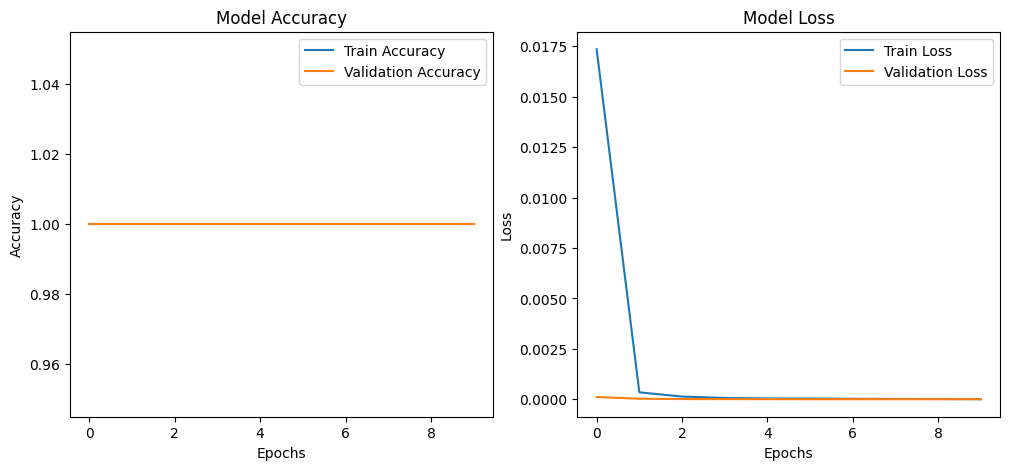

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.show()